# COVID-19 Patient Data Analysis



### Data Analytics Minor Project

**Tools Used:**
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")

In [47]:
df = pd.read_csv("patient.csv")

df.head()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


# Data Understanding

In [48]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB


In [49]:
# Column Names
df.columns

Index(['id', 'sex', 'birth_year', 'country', 'region', 'group',
       'infection_reason', 'infection_order', 'infected_by', 'contact_number',
       'confirmed_date', 'released_date', 'deceased_date', 'state'],
      dtype='object')

In [50]:
# Statistical Summary
df.describe()

,id,birth_year,infection_order,infected_by,contact_number
count,4212.000000,292.000000,35.000000,62.000000,32.000000
mean,2106.500000,1973.184932,2.257143,330.741935,96.843750
std,1216.043996,17.336573,1.357828,458.786744,224.669522
min,1.000000,1937.000000,1.000000,3.000000,0.000000
25%,1053.750000,1959.000000,1.000000,29.250000,2.750000
50%,2106.500000,1972.000000,2.000000,126.000000,16.500000
75%,3159.250000,1987.000000,3.000000,372.000000,69.750000
max,4212.000000,2018.000000,6.000000,1768.000000,1160.000000


## Observation

- The dataset contains COVID-19 patient records.
- It includes demographic and clinical information.
- Some columns contain missing values which will be handled in the Data Cleaning section.

# Data Cleaning

In [51]:
# Missing Values
df.isnull().sum()

id                     0
sex                 3894
birth_year          3920
country                0
region              3907
group               4136
infection_reason    4082
infection_order     4177
infected_by         4150
contact_number      4180
confirmed_date         0
released_date       4184
deceased_date       4199
state                  0
dtype: int64

## Observation

- The dataset contains a large number of missing values.
- Columns such as `id`, `country`, `confirmed_date`, and `state` are complete.
- Several columns like `sex`, `birth_year`, `region`, and `released_date` contain many missing values.
- These missing values will be considered during further analysis.

# Duplicate Rows


In [52]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate rows are present in the dataset.

## Date Conversion

In [53]:
df["confirmed_date"] = pd.to_datetime(df["confirmed_date"])
df["released_date"] = pd.to_datetime(df["released_date"])
df["deceased_date"] = pd.to_datetime(df["deceased_date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                4212 non-null   int64         
 1   sex               318 non-null    object        
 2   birth_year        292 non-null    float64       
 3   country           4212 non-null   object        
 4   region            305 non-null    object        
 5   group             76 non-null     object        
 6   infection_reason  130 non-null    object        
 7   infection_order   35 non-null     float64       
 8   infected_by       62 non-null     float64       
 9   contact_number    32 non-null     float64       
 10  confirmed_date    4212 non-null   datetime64[ns]
 11  released_date     28 non-null     datetime64[ns]
 12  deceased_date     13 non-null     datetime64[ns]
 13  state             4212 non-null   object        
dtypes: datetime64[ns](3), fl

# Exploratory Data Analysis (EDA)

## Gender Analysis

In [54]:
gender = df["sex"].value_counts()
gender

sex
female    163
male      155
Name: count, dtype: int64

### Gender Distribution (Bar chart)

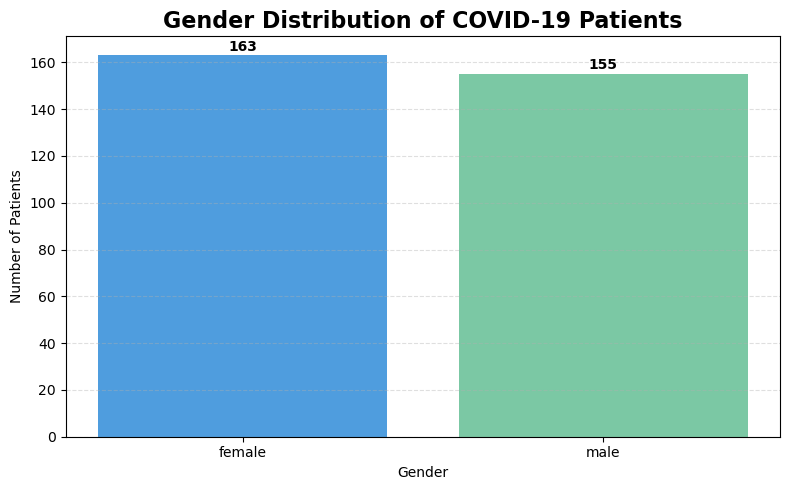

In [55]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    gender.index,
    gender.values,
    color=["#4F9DDE", "#7BC8A4"]
)

plt.title("Gender Distribution of COVID-19 Patients",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        int(height),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Observation

### Observation

- Female patients (163) are slightly more than male patients (155).
- The gender distribution is nearly balanced.
- No significant gender difference is observed in the available data.

### Gender Distribution (Pie Chart)

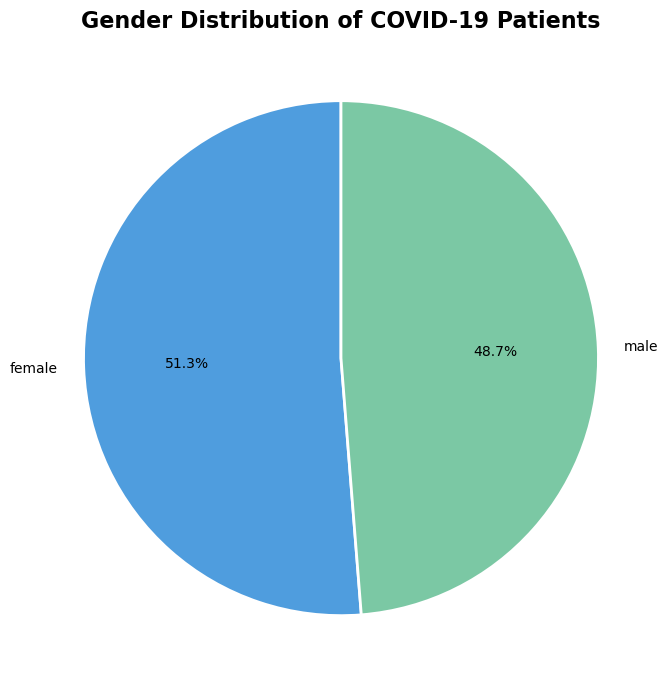

In [56]:
plt.figure(figsize=(7,7))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4F9DDE", "#7BC8A4"],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title(
    "Gender Distribution of COVID-19 Patients",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Observation

- Female patients represent 51.3% of the available records.
- Male patients represent 48.7% of the available records.
- The gender distribution is almost balanced, with a slightly higher proportion of female patients.

## Age Analysis

In [57]:
# Create Age Column
df["age"] = 2020 - df["birth_year"]

# Display first few ages
df["age"].head()

0    36.0
1    56.0
2    54.0
3    56.0
4    33.0
Name: age, dtype: float64

### Age Distribution (Histogram)

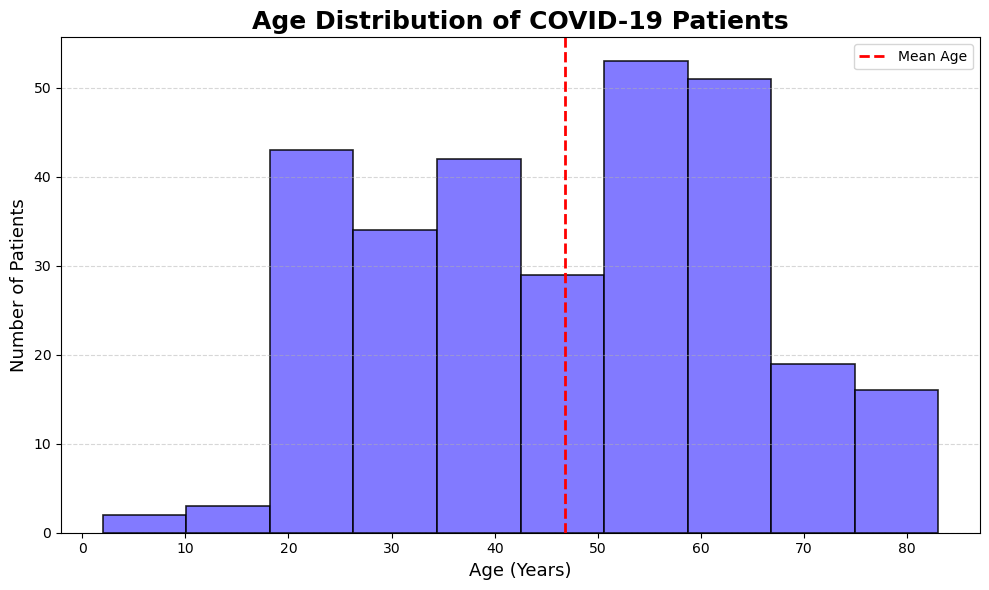

In [58]:
plt.figure(figsize=(10,6))

plt.hist(df['age'].dropna(),
         bins=10,
         color='#6C63FF',
         edgecolor='black',
         linewidth=1.2,
         alpha=0.85)

plt.title("Age Distribution of COVID-19 Patients",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Age (Years)", fontsize=13)
plt.ylabel("Number of Patients", fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mean age line
plt.axvline(df['age'].mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label='Mean Age')

plt.legend()

plt.tight_layout()
plt.show()

### Observation

- Most COVID-19 patients are between 20 and 70 years of age.
- The highest number of patients falls in the middle-age groups.
- Very few patients are below 20 years of age.
- The number of patients decreases in the higher age groups.

### Age Distribution (Box Plot)

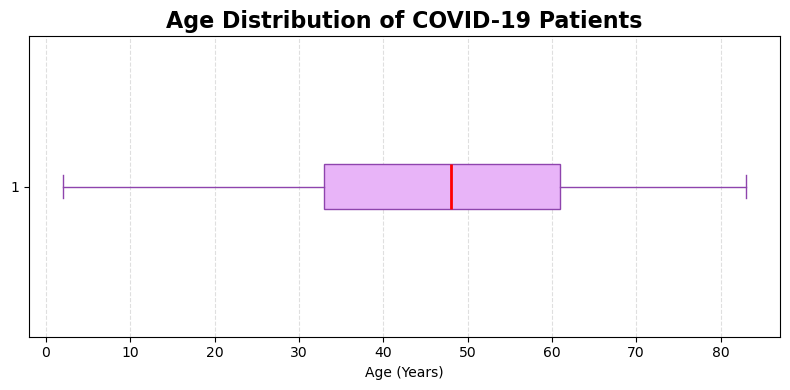

In [59]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["age"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#E8B4F8", color="#8E44AD"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="#8E44AD"),
    capprops=dict(color="#8E44AD"),
    flierprops=dict(
        marker="o",
        markerfacecolor="#FF69B4",
        markersize=6,
        markeredgecolor="black"
    )
)

plt.title(
    "Age Distribution of COVID-19 Patients",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age (Years)")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Observation

- Most patients are between 30 and 60 years of age.
- The median age is around 48 years.
- A few patients belong to very young and very old age groups.
- No significant extreme outliers are observed.

## State Analysis


### State Distribution (Bar Chart)

In [60]:
# Count patients by state
state = df["state"].value_counts()

state.head(10)

state
isolated    4171
released      28
deceased      13
Name: count, dtype: int64

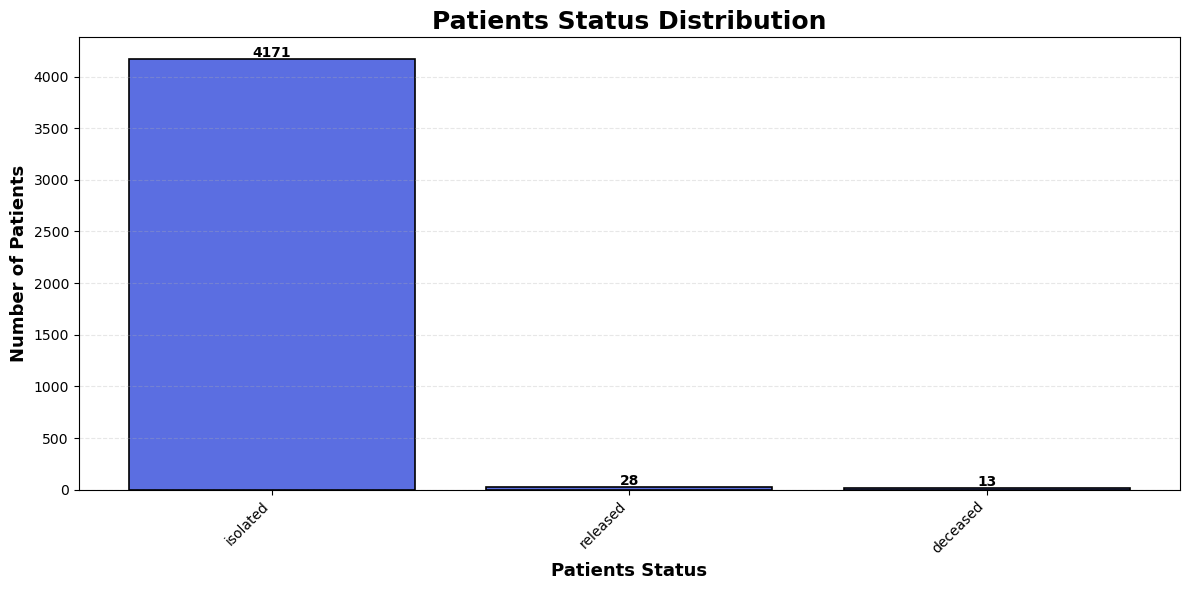

In [61]:
# Count patients by state
state = df["state"].value_counts().head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(
    state.index,
    state.values,
    color="#5B6EE1",      # Professional Indigo Blue
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Patients Status Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Patients Status",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Patients",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Show values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Observation

- Most patients are in the **isolated** category.
- A smaller number of patients have been **released**.
- Very few patients are recorded as **deceased**.
- This indicates that the majority of patients were still under isolation at the time the data was collected.

### Patient Status Distribution (Pie Chart)

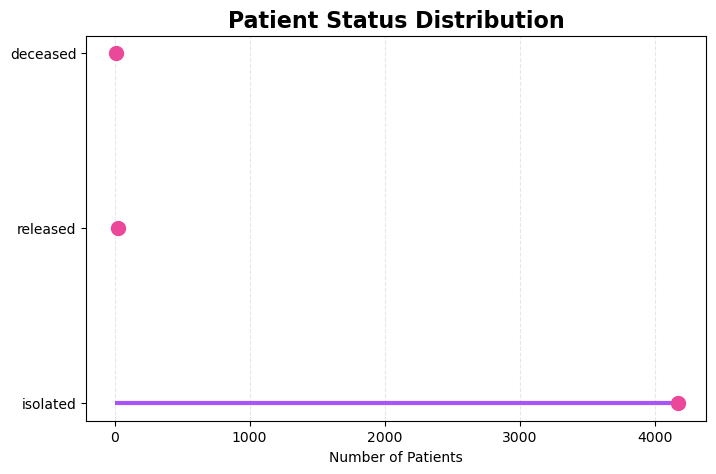

In [62]:
status = df["state"].value_counts()

plt.figure(figsize=(8,5))

plt.hlines(
    y=status.index,
    xmin=0,
    xmax=status.values,
    color="#A855F7",
    linewidth=3
)

plt.plot(
    status.values,
    status.index,
    "o",
    color="#EC4899",
    markersize=10
)

plt.title("Patient Status Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Number of Patients")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

### Observation

- The majority of patients are in the isolated category.
- Released patients represent a small proportion of the dataset.
- Deceased patients account for the smallest percentage.
- The pie chart clearly highlights the dominance of isolated cases.

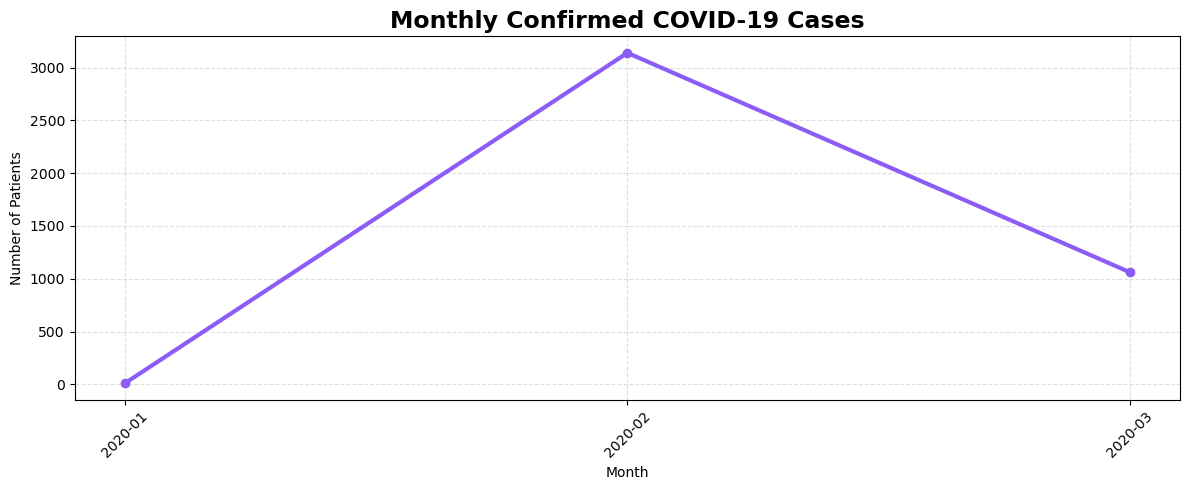

In [63]:
# Confirmed Cases by Month

monthly_cases = df["confirmed_date"].dt.to_period("M").value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_cases.index.astype(str),
    monthly_cases.values,
    marker="o",
    color="#8B5CF6",
    linewidth=3
)

plt.title("Monthly Confirmed COVID-19 Cases", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
marker="o",
markersize=8,
linewidth=3,
color="#7C3AED"   # Purple
plt.grid(True, linestyle="--", alpha=0.4)
plt.title(
    "Monthly Confirmed COVID-19 Cases",
    fontsize=17,
    fontweight="bold"
)
plt.show()


### Observation

- The graph shows the monthly trend of confirmed COVID-19 cases.
- Some months recorded higher confirmed cases than others.
- This helps identify the peak period of infections in the dataset.

## Region Analysis

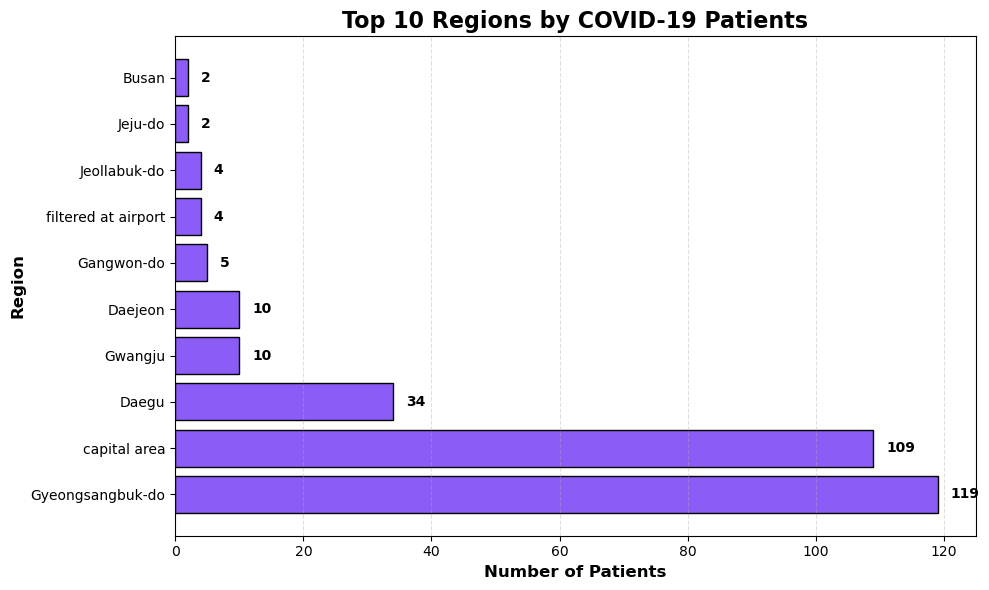

In [64]:


top_regions = df["region"].value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_regions.index,
    top_regions.values,
    color="#8B5CF6",      # Purple
    edgecolor="black"
)

plt.title(
    "Top 10 Regions by COVID-19 Patients",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Patients", fontsize=12, fontweight="bold")
plt.ylabel("Region", fontsize=12, fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

Observation

• A few regions reported significantly higher COVID-19 cases than others.
• The distribution of cases varies across different regions.
• This analysis helps identify the most affected regions in the dataset.

## Infection Reason Analysis

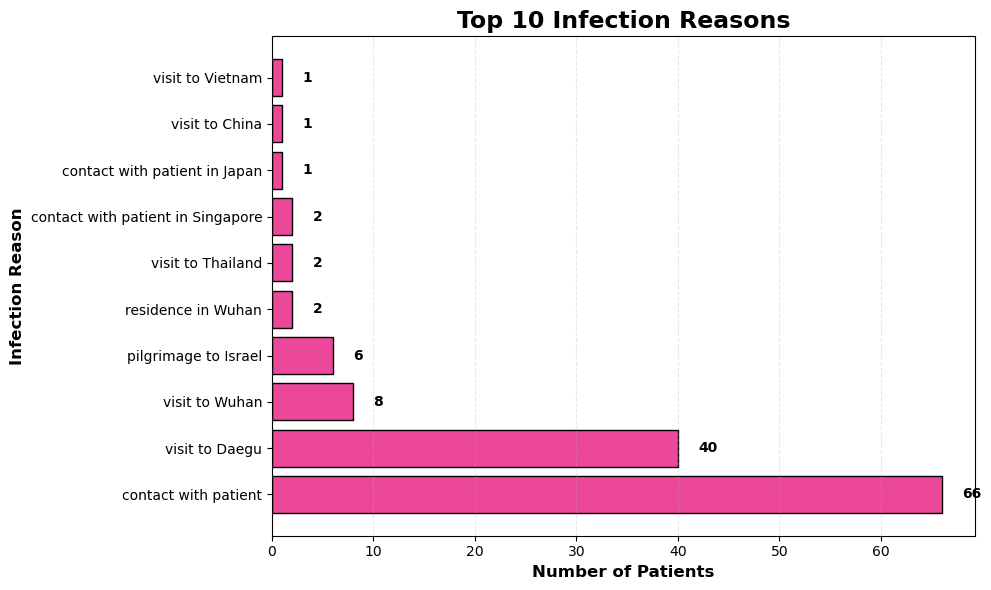

In [65]:


infection = df["infection_reason"].value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    infection.index,
    infection.values,
    color="#EC4899",      # Pink
    edgecolor="black"
)

plt.title(
    "Top 10 Infection Reasons",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Patients", fontsize=12, fontweight="bold")
plt.ylabel("Infection Reason", fontsize=12, fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Observation

• Some infection sources contributed to a large number of COVID-19 cases.
• A few infection reasons were much more common than others.
• This analysis helps identify the major sources of infection in the dataset.

In [66]:
print(df.columns)

Index(['id', 'sex', 'birth_year', 'country', 'region', 'group',
       'infection_reason', 'infection_order', 'infected_by', 'contact_number',
       'confirmed_date', 'released_date', 'deceased_date', 'state', 'age'],
      dtype='object')


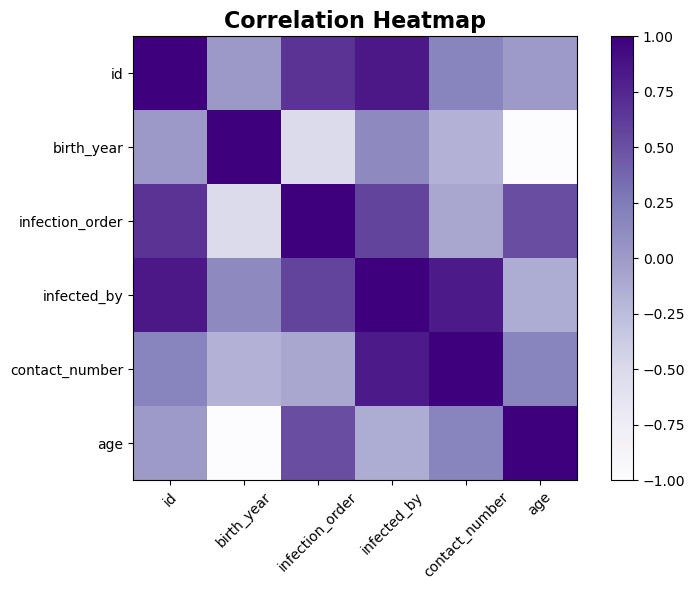

In [67]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="Purples", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

• Most numeric variables show weak correlation with each other.
• Some variables have missing values, which limits strong relationships.
• The heatmap provides an overview of relationships among numerical features.

## Conclusion

In this project, the COVID-19 patient dataset was analyzed using Python. The dataset was cleaned by handling missing values, checking duplicates, and converting date columns into the correct format. Exploratory Data Analysis (EDA) was performed using different visualizations to understand patient demographics, age distribution, patient status, regional distribution, infection cases, and correlations between numerical features.

The analysis helped in understanding the dataset and identifying useful patterns through visualizations. This project also improved practical skills in Python, Pandas, Matplotlib, and data analysis techniques.